<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/Linear-model-for-regression/Regularized_vs_unregularized_LSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Weights WITHOUT regularization:
 [ 3.32721395e-01 -8.39940413e+00  3.40038222e+02 -3.09202949e+03
  1.36537781e+04 -3.44522694e+04  5.18889438e+04 -4.61295564e+04
  2.23588643e+04 -4.55931464e+03]

Weights WITH regularization:
 [ 0.67154994  2.16353058 -4.99315164 -3.01738298 -0.43005601  1.15637315
  1.76307326  1.67750482  1.15806257  0.39037854]


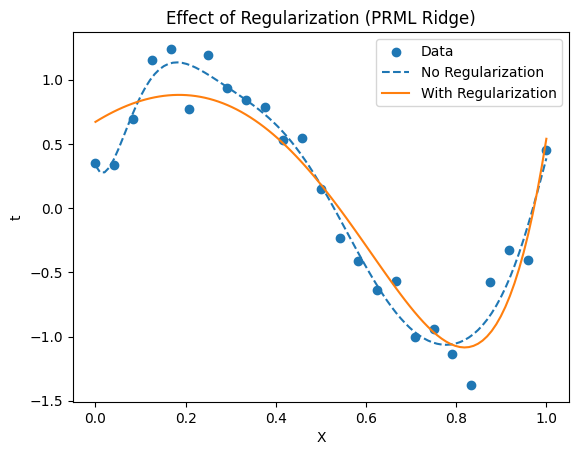

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate data (nonlinear truth)
# -----------------------------
np.random.seed(0)

N = 25
X = np.linspace(0, 1, N)

# True function (nonlinear)
t = np.sin(2 * np.pi * X) + np.random.normal(0, 0.2, N)

# -----------------------------
# 2. Create polynomial basis (PRML φ(x))
# -----------------------------
def create_design_matrix(X, M):
    """
    φ(x) = [1, x, x^2, ..., x^M]
    """
    Phi = np.zeros((len(X), M + 1))
    for j in range(M + 1):
        Phi[:, j] = X ** j
    return Phi

M = 9  # high degree → overfitting potential
Phi = create_design_matrix(X, M)

# -----------------------------
# 3. WITHOUT regularization
# -----------------------------
w_no_reg = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ t

# -----------------------------
# 4. WITH regularization (PRML ridge)
# -----------------------------
lam = 0.01  # try different values: 0.001, 0.1, 1

I = np.eye(M + 1)
w_reg = np.linalg.inv(lam * I + Phi.T @ Phi) @ Phi.T @ t

# -----------------------------
# 5. Predictions
# -----------------------------
X_test = np.linspace(0, 1, 100)
Phi_test = create_design_matrix(X_test, M)

y_no_reg = Phi_test @ w_no_reg
y_reg = Phi_test @ w_reg

# -----------------------------
# 6. Print weights
# -----------------------------
print("Weights WITHOUT regularization:\n", w_no_reg)
print("\nWeights WITH regularization:\n", w_reg)

# -----------------------------
# 7. Plot results
# -----------------------------
plt.scatter(X, t, label="Data")

plt.plot(X_test, y_no_reg, label="No Regularization", linestyle='--')
plt.plot(X_test, y_reg, label="With Regularization", linestyle='-')

plt.legend()
plt.title("Effect of Regularization (PRML Ridge)")
plt.xlabel("X")
plt.ylabel("t")
plt.show()